# Lab 14 · Hybrid search and neural reranking
## Goal
Compare lexical retrieval, dense retrieval, rank fusion, and an actual cross-encoder on the same corpus. Prerequisites: Labs 12–13, basic evaluation metrics. Plan 120 minutes: 20 baselines, 40 implementation, 35 evaluation, 25 failure analysis.

Use development questions to choose settings. Keep the public test split untouched until your final run; instructors should add private assessment cases. No improvement is assumed. The local cross-encoder is a teaching baseline, not a claim that its architecture or weights are SOTA.

## Setup
Complete the track README preflight first: install this track's pinned environment and editable package; start PostgreSQL/pgvector with Docker Compose; download the two pinned model snapshots; seed the invented course corpus. Select that Python environment as the kernel. These notebooks need the **whole `labs/rag` folder**, not a standalone upload. They use a real database and local neural models. Missing services or models are errors, not silently replaced by mocks.

Run worked cells first, then implement TODOs, set `RUN_EXERCISES=True`, restart, and run all. Instructor copies enable those checks. `RUN_GENERATION` stays false unless you deliberately enable the separately documented Gemini request. Offline here means no inference API calls after package/model downloads; PostgreSQL is still a real local service. All data are invented and English-language. Never use this teaching database or its public example keys for real student records.

In [1]:
import json
from pathlib import Path
from importlib.metadata import version
import numpy as np
from raglab.config import ROOT, DIMENSION
from raglab import db, models
from raglab.ingestion import corpus, chunk_documents, make_pipeline
RUN_EXERCISES = True
RUN_GENERATION = False
print({p:version(p) for p in ("llama-index-core","pgvector","psycopg","fastapi","sentence-transformers")})
with db.connect() as conn:
    print(conn.execute("SELECT extversion FROM pg_extension WHERE extname='vector'").fetchone())

{'llama-index-core': '0.14.25', 'pgvector': '0.5.0', 'psycopg': '3.3.6', 'fastapi': '0.142.4', 'sentence-transformers': '6.1.0'}
{'extversion': '0.8.1'}


## Steps
### 1. Compare candidates before generation
PostgreSQL full-text search here uses `ts_rank_cd`, **not BM25**. Lab vocabulary matters: rank fusion is also different from a neural reranker. The dense branch uses MiniLM embeddings; the reranker scores query/passage pairs with a separate cross-encoder. Its scores are not calibrated probabilities.

In [2]:
from raglab.retrieval import retrieve,rrf,document_metrics
query="E-204"
with db.connect() as conn:
    dense=db.search(conn,"alpha",models.embed([query])[0],query,10,"dense")
    lexical=db.search(conn,"alpha",None,query,10,"lexical")
print("Dense:",[r["doc_id"] for r in dense[:5]])
print("Lexical:",[r["doc_id"] for r in lexical[:5]])
fused=rrf([dense,lexical])
reranked=models.rerank(query,fused,5)
print("Reranked:",[(r["doc_id"],round(r["rerank_score"],3)) for r in reranked])

/private/tmp/course-rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10368.24it/s]

Dense: ['projector-error', 'accessibility', 'lost-equipment', 'projector-loans', 'booking-limit']
Lexical: ['projector-error']


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8620.12it/s]

Reranked: [('projector-error', 7.569), ('battery-guide', -11.223), ('booking-limit', -11.31), ('lost-equipment', -11.328), ('camera-extension', -11.342)]


### 2. TODO: implement reciprocal rank fusion (30 points)
Implement `student_rrf(rankings,c=60)` returning `(chunk_id,score)` pairs sorted by descending score then ID. Each ranking is a list of IDs; reject duplicates within a ranking and nonpositive/non-integer c. A document appearing in multiple rankings gets one contribution per list: `1/(c+rank)`, with rank starting at 1. Empty rankings return an empty result. Do not add raw lexical and cosine scores.

In [3]:
def student_rrf(rankings,c=60):
    if type(c) is not int or c<1: raise ValueError("invalid constant")
    scores={}
    for ranking in rankings:
        if len(ranking)!=len(set(ranking)): raise ValueError("duplicate ranking ID")
        for rank,key in enumerate(ranking,1): scores[key]=scores.get(key,0)+1/(c+rank)
    return sorted(scores.items(),key=lambda pair:(-pair[1],pair[0]))

In [4]:
if RUN_EXERCISES:
    assert student_rrf([])==[]
    assert student_rrf([["a"],["b","a"]])[0][0]=="a"
    assert np.isclose(dict(student_rrf([["a"],["b","a"]]))["a"],1/61+1/62)
    for rankings,c in [([["a","a"]],60),([],0),([],True)]:
        try: student_rrf(rankings,c)
        except ValueError: pass
        else: raise AssertionError("invalid fusion input accepted")

### 3. TODO: wire a real hybrid retrieval pipeline (40 points)
Implement `student_hybrid(conn,tenant,query,k=5)` using dense and lexical candidate queries (ten each), your rank fusion, and `models.rerank`. Preserve complete records and IDs; select at most twenty fused candidates before reranking. Reject k outside 1–20. There must be no score-based assumption that all queries have an answer.

In [5]:
def student_hybrid(conn,tenant,query,k=5):
    if type(k) is not int or not 1<=k<=20: raise ValueError("invalid k")
    d=db.search(conn,tenant,models.embed([query])[0],query,10,"dense")
    l=db.search(conn,tenant,None,query,10,"lexical")
    records={r["chunk_id"]:r for r in d+l}
    fused=student_rrf([[r["chunk_id"] for r in d],[r["chunk_id"] for r in l]])
    return models.rerank(query,[records[key] for key,score in fused[:20]],k)

In [6]:
if RUN_EXERCISES:
    with db.connect() as conn:
        assert student_hybrid(conn,"missing","camera",3)==[]
        rows=student_hybrid(conn,"alpha","E-204",3)
    assert 1<=len(rows)<=3 and len({r["chunk_id"] for r in rows})==len(rows)
    assert all("BETA-ONLY-MARKER" not in r["text"] for r in rows)
    assert all(np.isfinite(r["rerank_score"]) for r in rows)
    print("Hybrid retrieval exercised with real models and PostgreSQL")

Hybrid retrieval exercised with real models and PostgreSQL


### 4. Evaluate methods without assuming a winner
The evaluation unit is a document. Repeated chunks from the same document are deduplicated before computing metrics. Queries with no relevant document have null relevance metrics, not a fabricated perfect score. Evaluate abstention separately. The visible development corpus is small; its means do not establish general superiority.

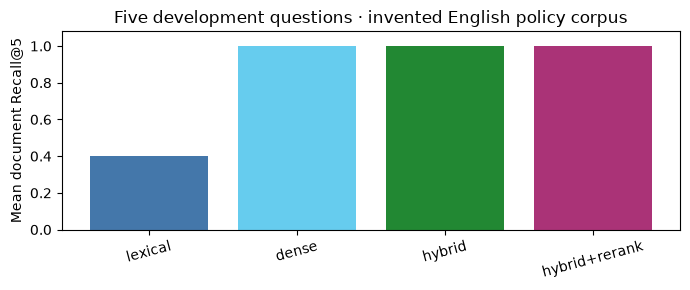

[{'question': 'q01', 'mode': 'lexical', 'recall': 0.0, 'mrr': 0.0, 'ndcg': 0.0}, {'question': 'q01', 'mode': 'dense', 'recall': 1.0, 'mrr': 1.0, 'ndcg': 1.0}, {'question': 'q01', 'mode': 'hybrid', 'recall': 1.0, 'mrr': 1.0, 'ndcg': 1.0}, {'question': 'q01', 'mode': 'hybrid+rerank', 'recall': 1.0, 'mrr': 1.0, 'ndcg': 1.0}]


In [7]:
from raglab.evaluate import evaluate
import matplotlib.pyplot as plt
report=evaluate("dev")
methods=["lexical","dense","hybrid","hybrid+rerank"]
means=[np.mean([r["recall"] for r in report["rows"] if r["mode"]==method and r["recall"] is not None]) for method in methods]
plt.figure(figsize=(7,3))
plt.bar(methods,means,color=["#4477AA","#66CCEE","#228833","#AA3377"])
plt.ylim(0,1.08);plt.ylabel("Mean document Recall@5")
plt.title("Five development questions · invented English policy corpus")
plt.xticks(rotation=15);plt.tight_layout();plt.show()
print([{k:r[k] for k in ("question","mode","recall","mrr","ndcg")} for r in report["rows"][:4]])

## Checks and submission
Produce a query-level table and a summary of Recall@5, MRR@5, nDCG@5, and observed time. Fix the dataset, model revisions, candidate count, and final k across comparisons; record changes rather than comparing incompatible configurations. Explain any tie, degradation, or missing relevant candidate. A reranker cannot recover a document absent from its candidates.

Add a no-answer query, an exact identifier, a paraphrase, and a conflicting policy case. Add a BM25 baseline using the supplied `rank-bm25` package if you want to compare lexical scoring methods; label it distinctly from PostgreSQL full-text ranking.

Rubric: fusion 30, integrated search 40, evaluation 20, failure analysis 10.

## Next Steps
Lab 15 exposes this retrieval pipeline as an HTTP service. Keep corpus text out of logs unless it is explicitly needed and appropriate.

References checked 2026-10-07: [PostgreSQL text-search ranking](https://www.postgresql.org/docs/current/textsearch-controls.html), [pgvector hybrid search](https://github.com/pgvector/pgvector#hybrid-search), [cross-encoder usage](https://www.sbert.net/docs/cross_encoder/usage/usage.html), [reranker model card](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2).